<h1><center>Stock Market Prediction</center></h1>
<hr>

<h1>Objective</h1>
<p>Training a neural network to predict the stock market, in Python with Pytorch using an LSTM-based architecture (Long-term short-term model)</p>
<hr>

**Importing the dependencies**

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

**Data Retrieval and Analysis**

In [12]:
ticker = '^NSEI'
df = yf.download(ticker, '2015-01-01')

/tmp/ipykernel_939/2695703139.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, '2015-01-01')
[*********************100%***********************]  1 of 1 completed


In [13]:
df

Price,Close,High,Low,Open,Volume
Ticker,^NSEI,^NSEI,^NSEI,^NSEI,^NSEI
Date,,,,,
2015-01-02,8395.450195,8410.599609,8288.700195,8288.700195,101900
2015-01-05,8378.400391,8445.599609,8363.900391,8407.950195,118200
2015-01-06,8127.350098,8327.849609,8111.350098,8325.299805,172800
2015-01-07,8102.100098,8151.200195,8065.450195,8118.649902,164100
2015-01-08,8234.599609,8243.500000,8167.299805,8191.399902,143800
...,...,...,...,...,...
2026-07-13,24211.000000,24259.800781,24000.199219,24039.400391,322700
2026-07-14,24052.050781,24157.099609,24023.699219,24068.000000,355800


<Axes: xlabel='Date'>

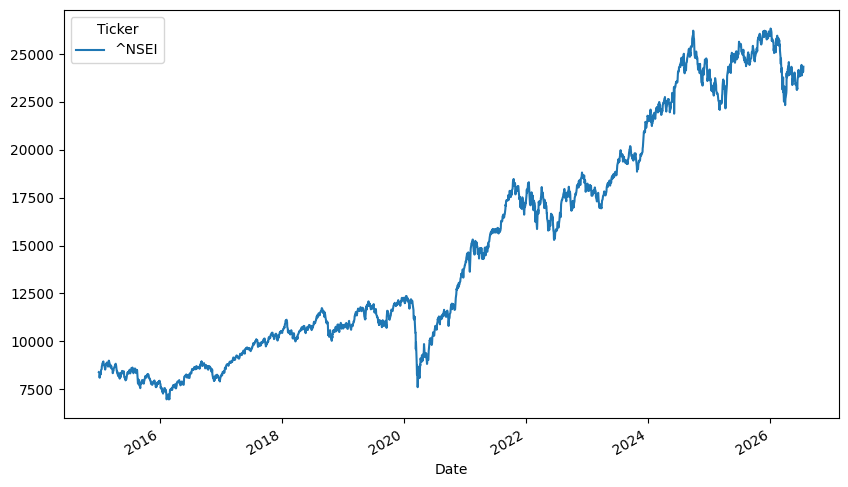

In [17]:
df.Close.plot(figsize=(10,6))

**Data Preprocessing**

In [18]:
scaler = StandardScaler()

df['Close'] = scaler.fit_transform(df['Close'])

In [19]:
df.Close

Ticker,^NSEI
Date,
2015-01-02,-1.104641
2015-01-05,-1.107500
2015-01-06,-1.149607
2015-01-07,-1.153842
2015-01-08,-1.131619
...,...
2026-07-13,1.547963
2026-07-14,1.521304
2026-07-15,1.525740


In [20]:
seq_length = 30
data = []

for i in range(len(df) - seq_length):
  data.append(df.Close[i:i+seq_length])

data = np.array(data)

In [23]:
data

array([[[-1.10464085],
        [-1.10750046],
        [-1.14960694],
        ...,
        [-1.06573786],
        [-1.05162422],
        [-1.03586677]],

       [[-1.10750046],
        [-1.14960694],
        [-1.1538419 ],
        ...,
        [-1.05162422],
        [-1.03586677],
        [-1.03522111]],

       [[-1.14960694],
        [-1.1538419 ],
        [-1.13161891],
        ...,
        [-1.03586677],
        [-1.03522111],
        [-1.02519976]],

       ...,

       [[ 1.42595475],
        [ 1.41288067],
        [ 1.41471742],
        ...,
        [ 1.54727587],
        [ 1.54796346],
        [ 1.52130429]],

       [[ 1.41288067],
        [ 1.41471742],
        [ 1.40635625],
        ...,
        [ 1.54796346],
        [ 1.52130429],
        [ 1.52574039]],

       [[ 1.41471742],
        [ 1.40635625],
        [ 1.36548271],
        ...,
        [ 1.52130429],
        [ 1.52574039],
        [ 1.52477599]]])

In [29]:
train_size = int(len(df) * 0.8)

X_train = torch.from_numpy(data[:train_size, :-1, :]).type(torch.Tensor).to(device)
y_train = torch.from_numpy(data[:train_size, -1, :]).type(torch.Tensor).to(device)
X_test = torch.from_numpy(data[train_size:, :-1, :]).type(torch.Tensor).to(device)
y_test = torch.from_numpy(data[train_size:, -1, :]).type(torch.Tensor).to(device)

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

# For time-series, we keep shuffle=False to preserve the temporal order
train_data = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_data, batch_size=32, shuffle=False)

test_data = TensorDataset(X_test, y_test)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

In [30]:
X_train
y_train

tensor([[-1.0359],
        [-1.0352],
        [-1.0252],
        ...,
        [ 1.1700],
        [ 1.1864],
        [ 1.1946]], device='cuda:0')

In [31]:
class PredictionModel(nn.Module):
  def __init__(self, input_dim, hidden_dim, num_layers, output_dim, dropout=0.2):
    super(PredictionModel, self).__init__()

    self.num_layers = num_layers
    self.hidden_dim = hidden_dim

    # LSTM with dropout for regularization
    self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout if num_layers > 1 else 0)

    # LayerNorm helps stabilize training in LSTMs
    self.layer_norm = nn.LayerNorm(hidden_dim)

    # Fully connected layer for the final prediction
    self.fc = nn.Linear(hidden_dim, output_dim)

    self._init_weights()

  def _init_weights(self):
    for name, param in self.lstm.named_parameters():
      if 'weight' in name:
        nn.init.xavier_uniform_(param)
      elif 'bias' in name:
        nn.init.constant_(param, 0.0)

  def forward(self, x):
    # Initialize hidden and cell states
    h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
    c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)

    # Forward propagate LSTM
    out, _ = self.lstm(x, (h0, c0))

    out = out[:, -1, :]
    out = self.layer_norm(out)
    out = self.fc(out)

    return out

In [32]:
model = PredictionModel(input_dim=1, hidden_dim=64, num_layers=2, output_dim=1).to(device)

In [33]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [35]:
num_epochs = 200

for i in range(num_epochs):
  y_train_pred = model(X_train)

  loss = criterion(y_train_pred, y_train)

  if i % 20 == 0:
    print(f'Epoch {i}/{num_epochs}, Loss: {loss.item()}')

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

Epoch 0/200, Loss: 0.002366704400628805
Epoch 20/200, Loss: 0.002305506030097604
Epoch 40/200, Loss: 0.0021995205897837877
Epoch 60/200, Loss: 0.002205848228186369
Epoch 80/200, Loss: 0.002204297576099634
Epoch 100/200, Loss: 0.0020339954644441605
Epoch 120/200, Loss: 0.0020721587352454662
Epoch 140/200, Loss: 0.0019495084416121244
Epoch 160/200, Loss: 0.0019891068805009127
Epoch 180/200, Loss: 0.0019271740457043052


In [36]:
model.eval()
with torch.no_grad():
    # Generate predictions on the test set
    test_predictions = model(X_test)

    # Move to CPU and convert to numpy for visualization
    test_predictions = test_predictions.cpu().numpy()
    y_test_cpu = y_test.cpu().numpy()

# Inverse transform to see the real price values
# Note: ensure scaler was fit only on training data in production,
# but here we use the existing 'scaler' instance.
predictions_rescaled = scaler.inverse_transform(test_predictions)
actual_rescaled = scaler.inverse_transform(y_test_cpu)

# Calculate RMSE
rmse = root_mean_squared_error(actual_rescaled, predictions_rescaled)
print(f"Test RMSE: {rmse:.2f}")

Test RMSE: 595.94


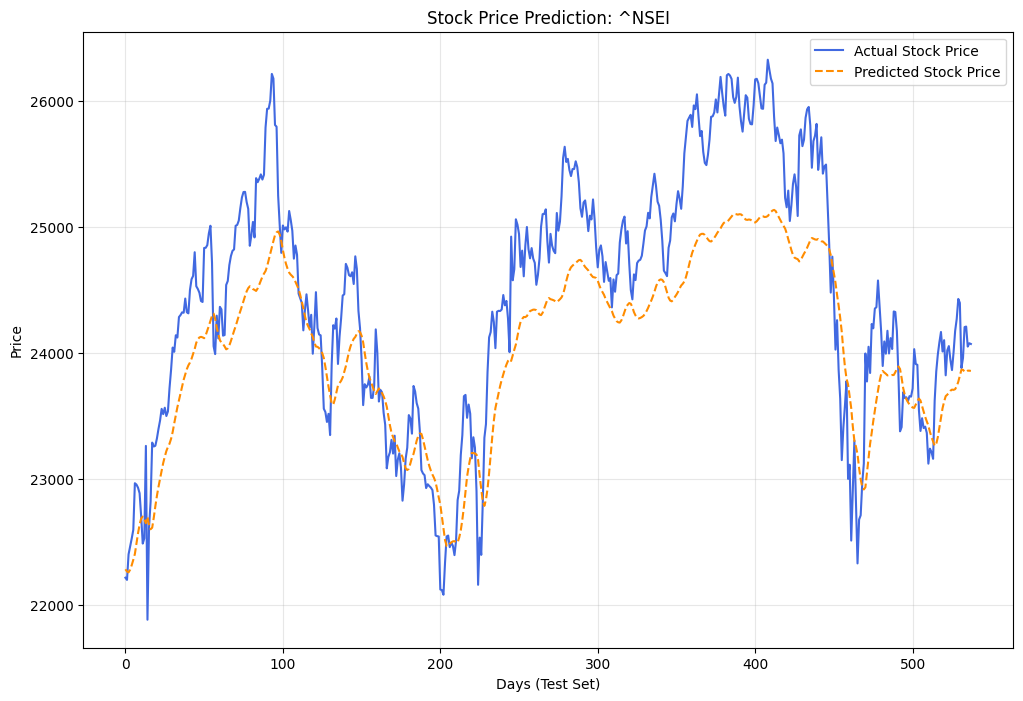

In [39]:
plt.figure(figsize=(12, 8))
plt.plot(actual_rescaled, label='Actual Stock Price', color='royalblue')
plt.plot(predictions_rescaled, label='Predicted Stock Price', color='darkorange', linestyle='--')
plt.title(f'Stock Price Prediction: {ticker}')
plt.xlabel('Days (Test Set)')
plt.ylabel('Price')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

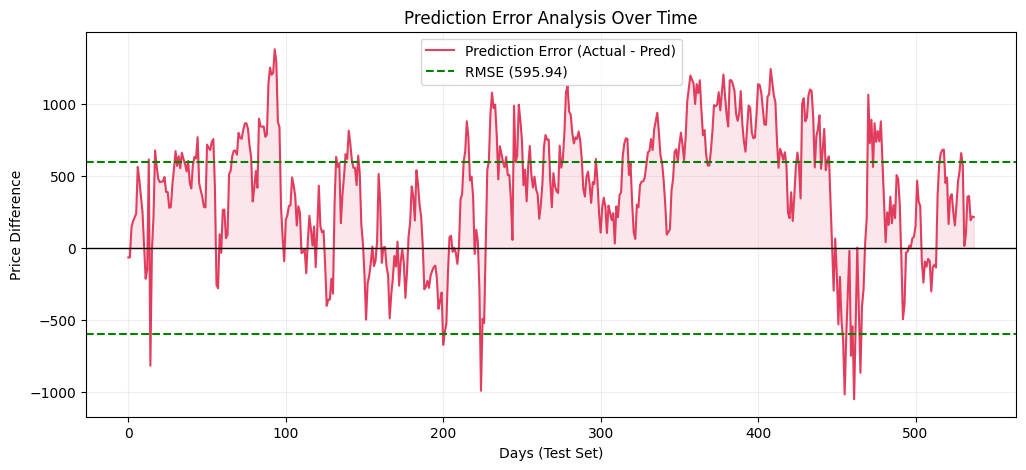

In [40]:
# Calculate daily error (Residuals)
error = actual_rescaled - predictions_rescaled

plt.figure(figsize=(12, 5))
plt.plot(error, label='Prediction Error (Actual - Pred)', color='crimson', alpha=0.8)
plt.axhline(y=0, color='black', linestyle='-', linewidth=1)
plt.axhline(y=rmse, color='green', linestyle='--', label=f'RMSE ({rmse:.2f})')
plt.axhline(y=-rmse, color='green', linestyle='--')

plt.title('Prediction Error Analysis Over Time')
plt.xlabel('Days (Test Set)')
plt.ylabel('Price Difference')
plt.legend()
plt.grid(True, alpha=0.2)
plt.fill_between(range(len(error)), error.flatten(), 0, color='crimson', alpha=0.1)
plt.show()